<a href="https://colab.research.google.com/github/SHAHAB-UDDIN54/Machine_learning-with-Shah/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
dataset = pd.read_excel("/content/home_price_dataset.xlsx")
dataset.head(5)

,Size_sqft,Bedrooms,Bathrooms,Location_Score,Price
0,883,4,2,4.42,228395
1,542,4,4,2.61,148637
2,3850,1,3,7.89,644315
3,1674,6,3,5.00,368979
4,3032,6,2,4.20,557254


In [4]:
dataset.shape

(50, 5)

In [5]:
dataset.describe()

,Size_sqft,Bedrooms,Bathrooms,Location_Score,Price
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,2530.980000,3.340000,2.560000,5.382800,460159.560000
std,1125.819475,1.611312,0.951047,2.546925,171824.073296
min,542.000000,1.000000,1.000000,1.050000,148637.000000
25%,1299.500000,2.000000,2.000000,3.380000,277791.750000
50%,2808.000000,3.000000,3.000000,4.710000,519400.000000
75%,3617.750000,4.000000,3.000000,7.630000,608647.500000
max,3905.000000,6.000000,4.000000,9.970000,719528.000000


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Size_sqft       50 non-null     int64  
 1   Bedrooms        50 non-null     int64  
 2   Bathrooms       50 non-null     int64  
 3   Location_Score  50 non-null     float64
 4   Price           50 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 2.1 KB


In [7]:
dataset.isnull().sum()

,0
Size_sqft,0
Bedrooms,0
Bathrooms,0
Location_Score,0
Price,0


In [8]:
dataset.notnull().sum()

,0
Size_sqft,50
Bedrooms,50
Bathrooms,50
Location_Score,50
Price,50


In [14]:
x = dataset[["Bedrooms"]]
y  = dataset["Price"]

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [18]:
print(f"Training samples:{x_train.shape[0]}")
print(f"testing samples:{x_test.shape[0]}")

Training samples:40
testing samples:10


In [19]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [20]:
print("intercept(b):",model.intercept_)
print("Coefficients(m):",model.coef_)

intercept(b): 451041.4037269373
Coefficients(m): [197.54441945]


In [21]:
y_pred = model.predict(x_test)

In [23]:
new_house = np.array([[3]])
new_house_scaled= scaler.transform(new_house)
predicted_price  = model.predict(new_house_scaled)
print(f"Predicted Price: ${predicted_price[0]:.2f}")

Predicted Price: $450999.30


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [24]:
comparison = pd.DataFrame({"Actual Price":y_test,"Predicted Price":y_pred})
comparison.head(10)

,Actual Price,Predicted Price
13,275752,451123.140221
39,561356,451123.140221
30,534124,451246.983395
45,528861,450999.297048
17,612207,450999.297048
48,484137,450751.610701
26,290533,451123.140221
25,693261,450999.297048
32,497250,450875.453875
19,489039,451370.826568


In [27]:
from sklearn.metrics import mean_squared_error,r2_score

In [32]:
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

In [30]:
print(f"MSE (mean sq error):{mse:.2f}")
print(f"RMSE (root mean sq error):{rmse:.2f}")
print(f"R-squared (coefficient of determination):{r2:.4f}")

MSE (mean sq error):17098928824.68
RMSE (root mean sq error):130762.87
R-squared (coefficient of determination):-0.1389


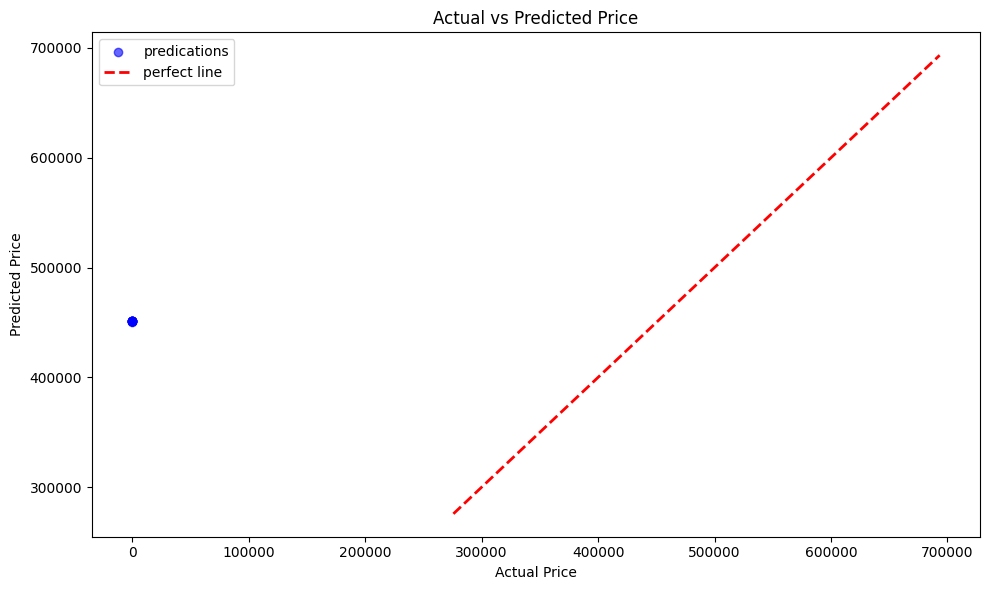

AttributeError: Rectangle.set() got an unexpected keyword argument 'edecolor'

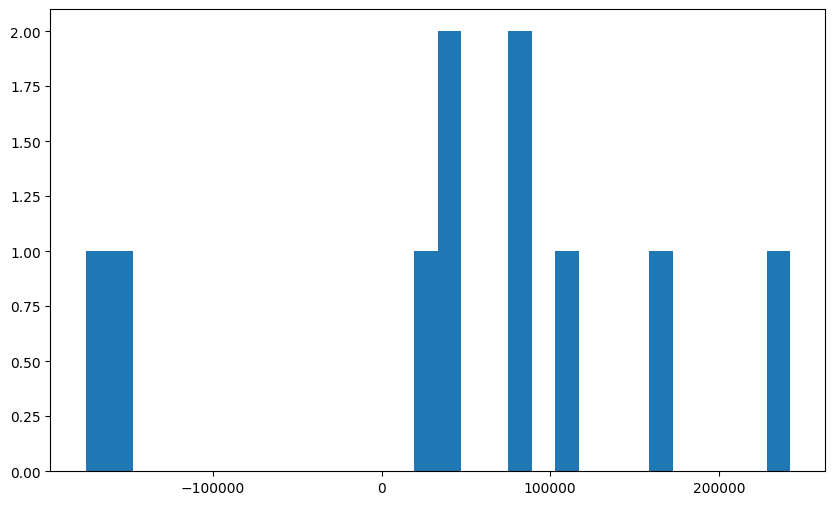

In [33]:
plt.figure(figsize=(10,6))
plt.scatter(x_test,y_pred,alpha = 0.6,color="blue", label="predications")
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],"r--",linewidth =2,label = "perfect line")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.legend( )
plt.tight_layout()
plt.show()


residuals = y_test - y_pred
plt.figure(figsize=(10,6))
plt.hist(residuals,bins=30,edgecolor ="black")
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.show()